# Problem 1: House Price Prediction using Gradient Descent

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme()

In [2]:
df = pd.read_csv("Housing.csv")

df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
X = np.array(df["area"])
y = np.array(df["price"])

In [4]:
def make_prediction(X, y, w, b):
    m = X.shape[0]
    pred_list = np.zeros((m,))

    for i in range(m):
        pred_list[i] = w * X[i] + b

    return pred_list

In [5]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0 

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost = cost + error_squared
    cost = cost / (2 * m)
    return cost

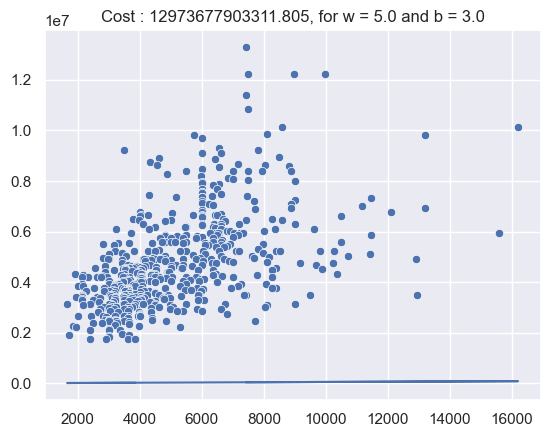

In [6]:
w = 5.0
b = 3.0

predictions = make_prediction(X, y, w=w, b=b)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost : {compute_cost(X, y, w = w, b = b)}, for w = {w} and b = {b}")
plt.show()

In [7]:
def calculate_gradient(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error
    return dj_dw / m, dj_db / m

In [8]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha = 0.01):
    w = w_input
    b = b_input
    cost_memo = []
    iteration = []

    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        cost_memo.append(cost)
        iteration.append(i)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost: {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")
    return w, b, cost_memo, iteration

In [10]:
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input = 0, b_input = 0, max_iter = 1000, alpha = 1e-9)

Iteration 0: Cost: 13106789099004.6172, w: 0.0048, b: 0.0048
Iteration 100: Cost: 13094069418772.3027, w: 0.4808, b: 0.4813
Iteration 200: Cost: 13081363363075.5625, w: 0.9566, b: 0.9576
Iteration 300: Cost: 13068670917613.1387, w: 1.4321, b: 1.4337
Iteration 400: Cost: 13055992068098.7031, w: 1.9074, b: 1.9095
Iteration 500: Cost: 13043326800260.8027, w: 2.3825, b: 2.3851
Iteration 600: Cost: 13030675099842.6914, w: 2.8573, b: 2.8604
Iteration 700: Cost: 13018036952602.5762, w: 3.3319, b: 3.3355
Iteration 800: Cost: 13005412344313.4746, w: 3.8062, b: 3.8103
Iteration 900: Cost: 12992801260763.0801, w: 4.2803, b: 4.2849


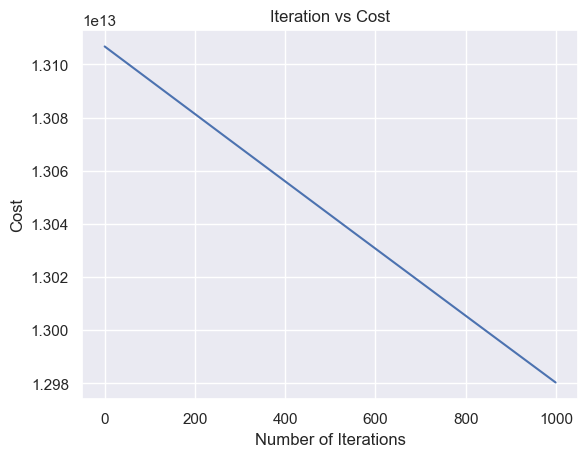

In [11]:
plt.plot(iter_list, cost_memo)
plt.title("Iteration vs Cost")
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.show()

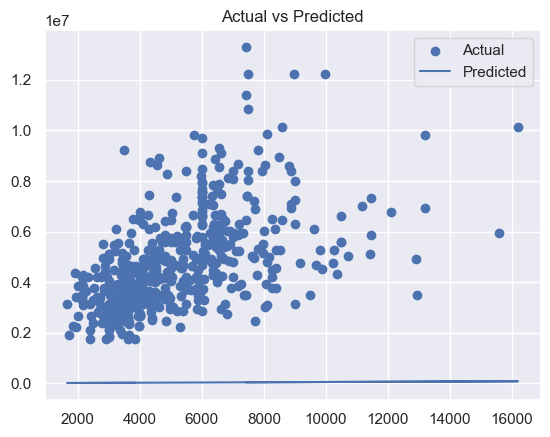

In [13]:
predictions_final = make_prediction(X, y, w_final, b_final)

plt.scatter(X, y, label="Actual")
plt.plot(X, predictions_final, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [14]:
print("Final w =", w_final)
print("Final b =", b_final)
print("Final cost =", cost_memo[-1])

Final w = 4.7493472046341925
Final b = 4.754497745918597
Final cost = 12980329596653.445


# Problem 2: Student Performance Prediction

In [15]:
df = pd.read_csv("StudentsPerformance.csv")
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [24]:
X = np.array(df["reading score"])
y = np.array(df["math score"])

In [31]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost = cost + error_squared

    cost = cost / (2 * m)
    return cost

In [32]:
def calculate_gradient(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error

    return dj_dw / m, dj_db / m

In [33]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha = 0.01):
    w = w_input
    b = b_input
    cost_memo = []
    iteration = []

    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        cost_memo.append(cost)
        iteration.append(i)

        if i % 50 == 0:
            print(f"Iteration {i}: Cost :{cost:0.4f}, w : {w:0.4f}, b : {b:0.4f}")

    return w, b, cost_memo, iteration

In [35]:
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=0, b_input=0, max_iter=500, alpha = 0.00001)

Iteration 0: Cost :2078.4964, w : 0.0475, b : 0.0007
Iteration 50: Cost :51.3232, w : 0.8812, b : 0.0124
Iteration 100: Cost :39.2992, w : 0.9454, b : 0.0134
Iteration 150: Cost :39.2278, w : 0.9503, b : 0.0136
Iteration 200: Cost :39.2274, w : 0.9507, b : 0.0138
Iteration 250: Cost :39.2273, w : 0.9507, b : 0.0139
Iteration 300: Cost :39.2273, w : 0.9507, b : 0.0141
Iteration 350: Cost :39.2272, w : 0.9507, b : 0.0143
Iteration 400: Cost :39.2272, w : 0.9507, b : 0.0144
Iteration 450: Cost :39.2271, w : 0.9507, b : 0.0146


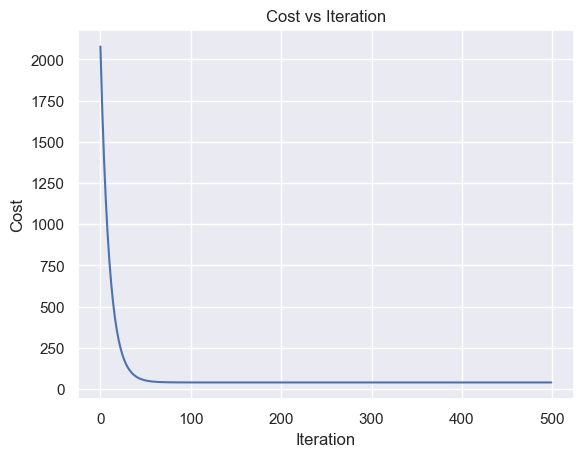

In [36]:
plt.plot(iter_list, cost_memo)
plt.title("Cost vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [37]:
print("Final w:", w_final)
print("Final b:", b_final)
print("Final Cost:", cost_memo[-1])

Final w: 0.9507356013431514
Final b: 0.014724188205400224
Final Cost: 39.22706592345968


# Problem 3: Insurance Charges Prediction

In [38]:
df = pd.read_csv("insurance.csv")
df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [40]:
X = np.array(df["age"])
y = np.array(df["charges"])

In [47]:
# Cost Function

def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost = cost + error_squared

    cost = cost / (2 * m)
    return cost

In [48]:
# Gradient Calculation

def gradient_calculate(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error
    return dj_dw / m, dj_db / m

In [49]:
# Gradient Descent

def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
    w = w_input
    b = b_input
    cost_memo = []
    iteration = []

    for i in range(max_iter):
        dj_dw, dj_db = gradient_calculate(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db


        cost = compute_cost(X, y, w, b)
        cost_memo.append(cost)
        iteration.append(i)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost: {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")

    return w, b, cost_memo, iteration

In [51]:
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=0, b_input=0, max_iter=1000, alpha=0.00001)

Iteration 0: Cost: 158088092.2225, w: 5.7113, b: 0.1327
Iteration 100: Cost: 70026457.9271, w: 272.9466, b: 6.5331
Iteration 200: Cost: 67370101.9219, w: 319.3523, b: 7.9413
Iteration 300: Cost: 67289852.4161, w: 327.4051, b: 8.4825
Iteration 400: Cost: 67287306.8553, w: 328.7970, b: 8.8730
Iteration 500: Cost: 67287105.1317, w: 329.0320, b: 9.2373
Iteration 600: Cost: 67286974.1344, w: 329.0661, b: 9.5971
Iteration 700: Cost: 67286845.2988, w: 329.0654, b: 9.9560
Iteration 800: Cost: 67286716.5567, w: 329.0585, b: 10.3147
Iteration 900: Cost: 67286587.8459, w: 329.0506, b: 10.6734


In [53]:
# Initial Cost vs Final Cost
initial_cost = compute_cost(X, y, 0, 0)

print("Initial Cost: ", initial_cost)
print("Final Cost: ", cost_memo[-1])

Initial Cost:  161323436.79435247
Final Cost:  67286460.45112428


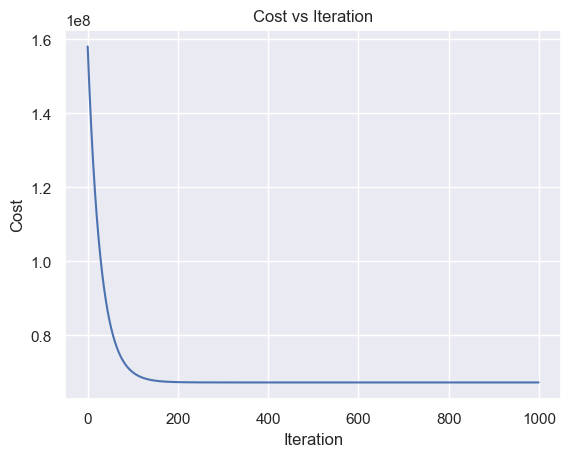

In [54]:
# Cost vs Iteration Plot

plt.plot(iter_list, cost_memo)
plt.title("Cost vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

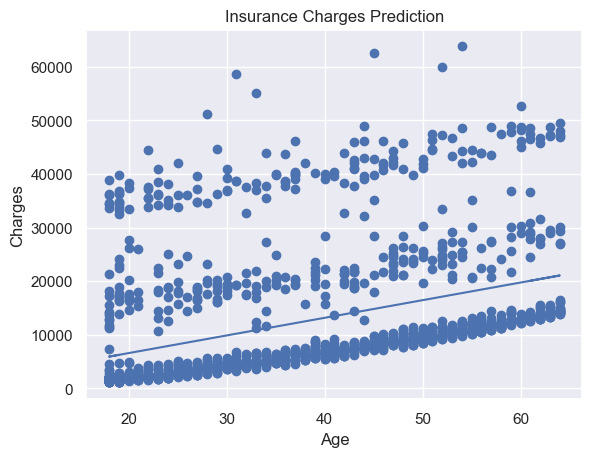

In [55]:
# Regression Line Visualization

predictions = w_final * X + b_final

plt.scatter(X, y)
plt.plot(X, predictions)

plt.title("Insurance Charges Prediction")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

In [56]:
print("Final w =", w_final)
print("Final b =", b_final)

Final w = 329.0426405897088
Final b = 11.028455845918227
